In [4]:
import pandas as pd

# Đọc file processed từ Lab 1
df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')
print(df.head())

   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...    TBM1    TBM2  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  6.9750  7.5500   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  4.5125  5.3750   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  5.9750  5.4375   
3    4  6.6  6.4  5.3  6.9  5.4  7.3  6.4  5.8  5.1  ...  6.2625  5.3125   
4    5  6.0  5.0  6.0  7.3  6.5  7.7  7.9  6.1  5.4  ...  6.5625  6.4625   

     TBM3  XL1  XL2  XL3   US_TBM1   US_TBM2   US_TBM3  KQXT  
0  6.8500    K    K    K  2.882540  3.083333  2.247191     0  
1  5.1500    Y   TB   TB  0.380952  1.011905  0.209738     0  
2  6.3250   TB   TB   TB  1.866667  1.071429  1.617978     1  
3  6.8500   TB   TB    K  2.158730  0.952381  2.247191     0  
4  6.9125    K   TB    K  2.463492  2.047619  2.322097     0  

[5 rows x 66 columns]


In [5]:
# Câu 1: Sắp xếp DH1 tăng dần
df_sorted_dh1 = df.sort_values('DH1', ascending=True)
print(df_sorted_dh1[['DH1']].head(10))

     DH1
53  1.00
43  1.25
5   1.50
72  1.50
83  1.75
87  1.75
38  2.00
12  2.00
79  2.00
73  2.00


In [6]:
# Câu 2: Sắp xếp DH2 tăng dần theo nhóm giới tính
df_sorted_dh2 = df.sort_values(['GT', 'DH2'], ascending=[True, True])
print(df_sorted_dh2[['GT', 'DH2']].head(10))

   GT   DH2
95  F  1.50
25  F  2.00
24  F  2.25
46  F  2.25
13  F  2.75
21  F  3.00
0   F  3.25
51  F  3.25
8   F  3.50
22  F  3.50


In [7]:
# Câu 3: Pivot table DH1 theo KT
pivot1 = df.groupby('KT')['DH1'].agg(
    count='count', sum='sum', mean='mean', median='median',
    min='min', max='max', std='std',
    Q1=lambda x: x.quantile(0.25),
    Q2=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75)
).round(2)
print(pivot1)

    count     sum  mean  median   min   max   std    Q1    Q2    Q3
KT                                                                 
A      49  163.50  3.34    3.25  1.00  6.50  1.27  2.25  3.25  4.25
A1      6   17.50  2.92    3.00  2.00  4.25  0.86  2.19  3.00  3.25
B       9   29.50  3.28    3.50  1.75  4.50  0.82  3.25  3.50  3.75
C      14   79.25  5.66    5.25  4.75  7.00  0.81  5.06  5.25  6.38
D1     22   84.25  3.83    3.75  1.25  6.75  1.37  3.00  3.75  4.88


In [8]:
# Câu 4: Pivot table DH1 theo KT và KV
pivot2 = df.groupby(['KT', 'KV'])['DH1'].agg(
    count='count', sum='sum', mean='mean', median='median',
    min='min', max='max', std='std',
    Q1=lambda x: x.quantile(0.25),
    Q2=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75)
).round(2)
print(pivot2)

        count    sum  mean  median   min   max   std    Q1    Q2    Q3
KT KV                                                                 
A  1       29  93.75  3.23    3.25  1.00  6.50  1.37  2.00  3.25  4.25
   2        9  31.75  3.53    3.50  2.00  6.25  1.43  2.25  3.50  4.25
   2NT     11  38.00  3.45    3.50  2.00  4.75  0.91  2.88  3.50  4.12
A1 1        2   4.75  2.38    2.38  2.00  2.75  0.53  2.19  2.38  2.56
   2NT      4  12.75  3.19    3.25  2.00  4.25  0.92  2.94  3.25  3.50
B  1        8  25.75  3.22    3.38  1.75  4.50  0.86  3.00  3.38  3.56
   2NT      1   3.75  3.75    3.75  3.75  3.75   NaN  3.75  3.75  3.75
C  1        8  43.50  5.44    5.25  4.75  7.00  0.73  5.00  5.25  5.44
   2        2  11.50  5.75    5.75  5.00  6.50  1.06  5.38  5.75  6.12
   2NT      4  24.25  6.06    6.00  5.25  7.00  0.94  5.25  6.00  6.81
D1 1       13  46.75  3.60    3.50  1.50  5.75  1.26  2.75  3.50  4.25
   2        8  33.75  4.22    4.50  1.25  6.75  1.62  3.56  4.50  5.00
   2NT

In [12]:
# @title Văn bản tiêu đề mặc định
# Câu 5: Pivot table DH1 theo KT, KV và DT
pivot3 = df.groupby(['KT', 'KV', 'DT'])['DH1'].agg(
    count='count', sum='sum', mean='mean', median='median',
    min='min', max='max', std='std',
    Q1=lambda x: x.quantile(0.25),
    Q2=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75)
).round(2)
print(pivot3)

            count    sum  mean  median   min   max   std    Q1    Q2    Q3
KT KV  DT                                                                 
A  1   0.0     29  93.75  3.23    3.25  1.00  6.50  1.37  2.00  3.25  4.25
   2   0.0      8  27.50  3.44    3.00  2.00  6.25  1.50  2.25  3.00  4.19
       6.0      1   4.25  4.25    4.25  4.25  4.25   NaN  4.25  4.25  4.25
   2NT 0.0     11  38.00  3.45    3.50  2.00  4.75  0.91  2.88  3.50  4.12
A1 1   0.0      2   4.75  2.38    2.38  2.00  2.75  0.53  2.19  2.38  2.56
   2NT 0.0      4  12.75  3.19    3.25  2.00  4.25  0.92  2.94  3.25  3.50
B  1   0.0      8  25.75  3.22    3.38  1.75  4.50  0.86  3.00  3.38  3.56
   2NT 0.0      1   3.75  3.75    3.75  3.75  3.75   NaN  3.75  3.75  3.75
C  1   0.0      8  43.50  5.44    5.25  4.75  7.00  0.73  5.00  5.25  5.44
   2   0.0      2  11.50  5.75    5.75  5.00  6.50  1.06  5.38  5.75  6.12
   2NT 0.0      4  24.25  6.06    6.00  5.25  7.00  0.94  5.25  6.00  6.81
D1 1   0.0     12  43.75 

In [ ]:
#PHần 2 nhỏ

    Tần số  Tần suất (%)
GT                      
M       52          52.0
F       48          48.0


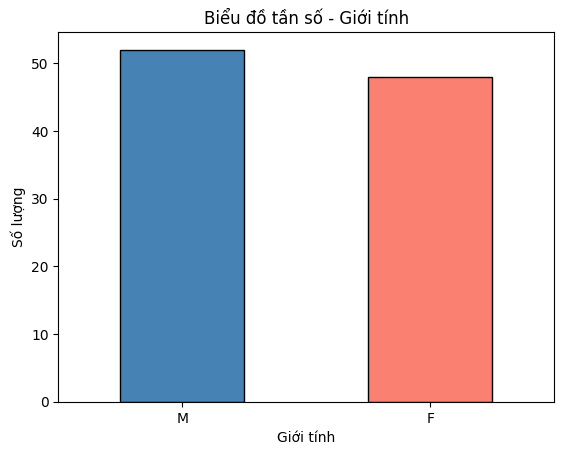

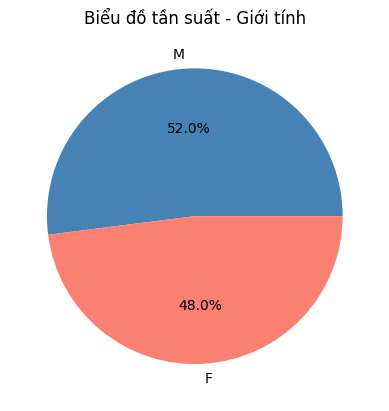

In [10]:
import matplotlib.pyplot as plt

# Câu 1: Trình bày biến GT
# Bảng tần số và tần suất
tan_so = df['GT'].value_counts()
tan_suat = df['GT'].value_counts(normalize=True).round(4) * 100

bang_gt = pd.DataFrame({'Tần số': tan_so, 'Tần suất (%)': tan_suat})
print(bang_gt)

# Biểu đồ cột (tần số)
tan_so.plot(kind='bar', color=['steelblue','salmon'], edgecolor='black')
plt.title('Biểu đồ tần số - Giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

# Biểu đồ tròn (tần suất)
tan_suat.plot(kind='pie', autopct='%1.1f%%', colors=['steelblue','salmon'])
plt.title('Biểu đồ tần suất - Giới tính')
plt.ylabel('')
plt.show()


Thống kê US_TBM1:
count    100.00
mean       2.02
std        0.99
min        0.00
25%        1.24
50%        2.18
75%        2.77
max        4.00
Name: US_TBM1, dtype: float64


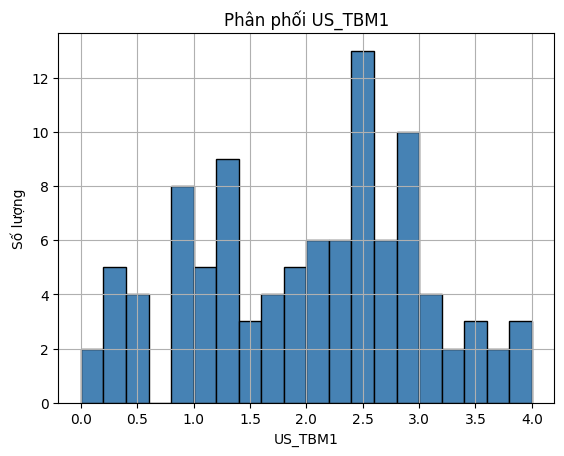


Thống kê US_TBM2:
count    100.00
mean       2.02
std        0.89
min        0.00
25%        1.25
50%        2.04
75%        2.71
max        4.00
Name: US_TBM2, dtype: float64


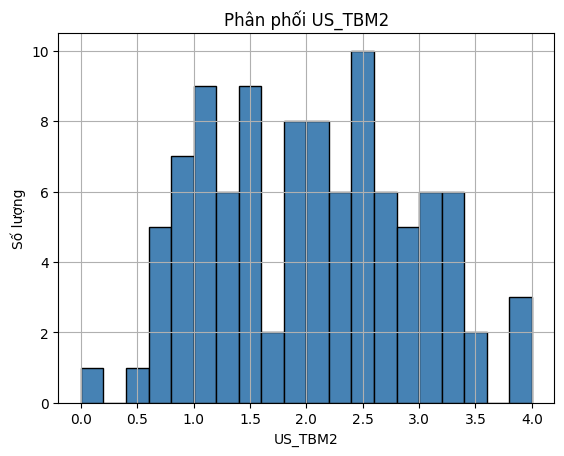


Thống kê US_TBM3:
count    100.00
mean       2.03
std        0.87
min        0.00
25%        1.42
50%        2.17
75%        2.70
max        4.00
Name: US_TBM3, dtype: float64


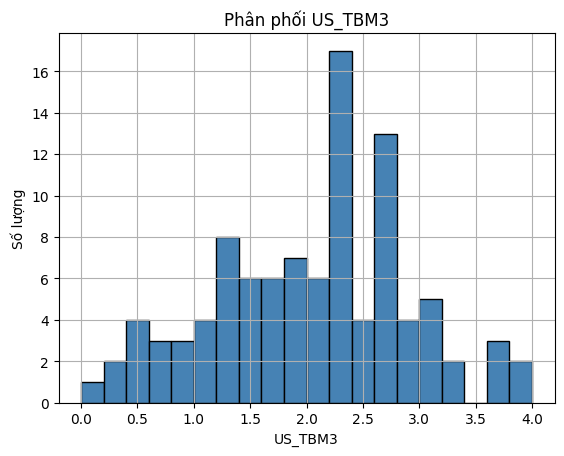

In [11]:
# Câu 2: Trình bày US_TBM1, US_TBM2, US_TBM3
for col in ['US_TBM1', 'US_TBM2', 'US_TBM3']:
    tan_so = df[col].value_counts().sort_index()
    print(f"\nThống kê {col}:")
    print(df[col].describe().round(2))

    df[col].hist(bins=20, edgecolor='black', color='steelblue')
    plt.title(f'Phân phối {col}')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.show()

     Tần số  Tần suất (%)
DT                       
0.0      50         96.15
1.0       1          1.92
6.0       1          1.92


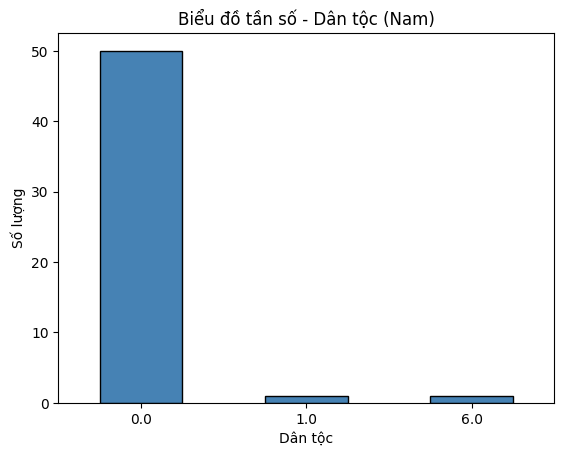

In [15]:
# Câu 3: Biến DT với học sinh nam
df_nam = df[df['GT'] == 'M']
tan_so = df_nam['DT'].value_counts()
tan_suat = df_nam['DT'].value_counts(normalize=True).round(4) * 100

bang_dt = pd.DataFrame({'Tần số': tan_so, 'Tần suất (%)': tan_suat})
print(bang_dt)

tan_so.plot(kind='bar', edgecolor='black', color='steelblue')
plt.title('Biểu đồ tần số - Dân tộc (Nam)')
plt.xlabel('Dân tộc')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

     Tần số  Tần suất (%)
KV                       
1         2         33.33
2         2         33.33
2NT       2         33.33


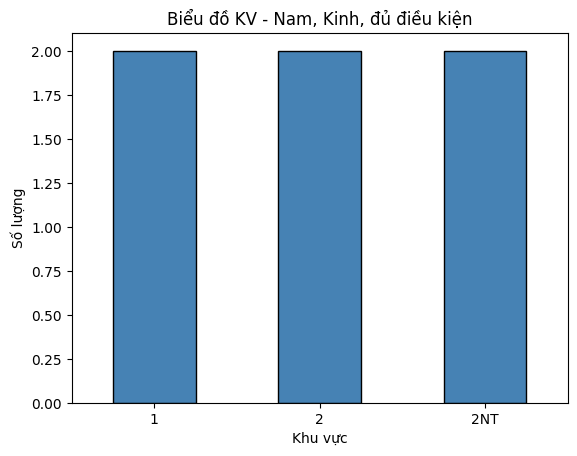

In [16]:
# Câu 4: Biến KV với học sinh nam, dân tộc Kinh, DH1>=5, DH2>=4, DH3>=4
dk = (df['GT'] == 'M') & (df['DT'] == 0) & (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)
df_loc = df[dk]

tan_so = df_loc['KV'].value_counts()
tan_suat = df_loc['KV'].value_counts(normalize=True).round(4) * 100
print(pd.DataFrame({'Tần số': tan_so, 'Tần suất (%)': tan_suat}))

tan_so.plot(kind='bar', edgecolor='black', color='steelblue')
plt.title('Biểu đồ KV - Nam, Kinh, đủ điều kiện')
plt.xlabel('Khu vực')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()


Thống kê DH1 (KV=2NT, >=5.0):
count    1.00
mean     6.75
std       NaN
min      6.75
25%      6.75
50%      6.75
75%      6.75
max      6.75
Name: DH1, dtype: float64


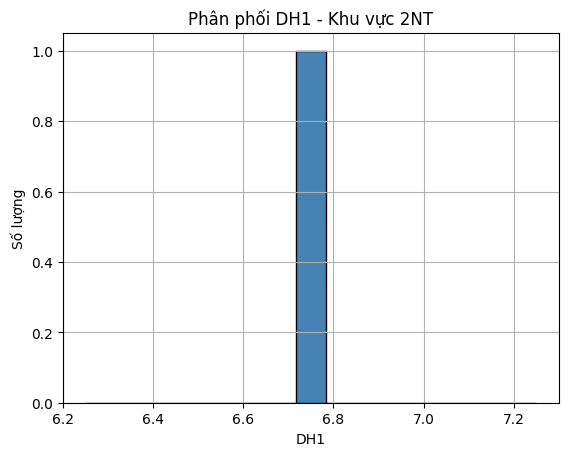


Thống kê DH2 (KV=2NT, >=5.0):
count    1.00
mean     5.25
std       NaN
min      5.25
25%      5.25
50%      5.25
75%      5.25
max      5.25
Name: DH2, dtype: float64


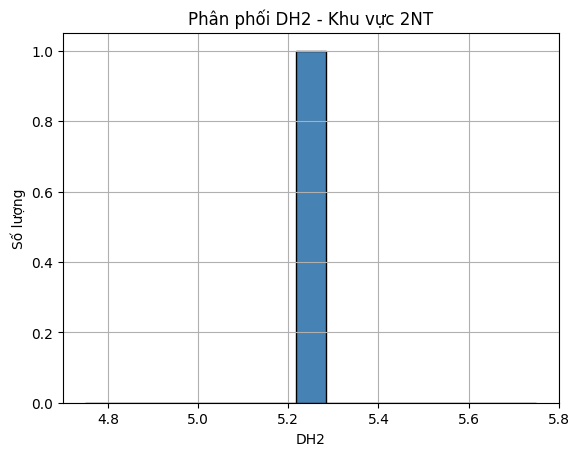


Thống kê DH3 (KV=2NT, >=5.0):
count    1.0
mean     5.0
std      NaN
min      5.0
25%      5.0
50%      5.0
75%      5.0
max      5.0
Name: DH3, dtype: float64


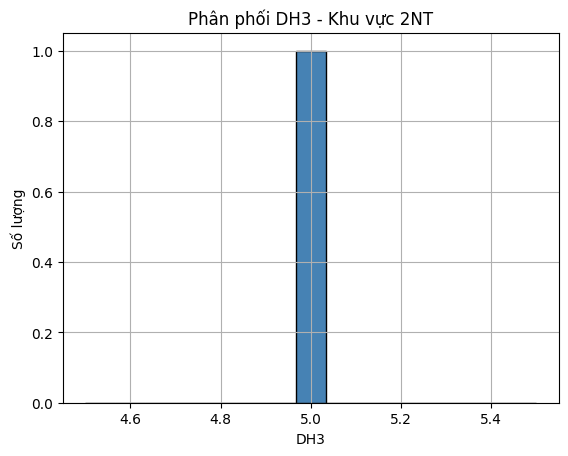

In [17]:
# Câu 5: DH1, DH2, DH3 >= 5.0 thuộc khu vực 2NT
df_2nt = df[(df['KV'] == '2NT') & (df['DH1'] >= 5.0) & (df['DH2'] >= 5.0) & (df['DH3'] >= 5.0)]

for col in ['DH1', 'DH2', 'DH3']:
    print(f"\nThống kê {col} (KV=2NT, >=5.0):")
    print(df_2nt[col].describe().round(2))

    df_2nt[col].hist(bins=15, edgecolor='black', color='steelblue')
    plt.title(f'Phân phối {col} - Khu vực 2NT')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.show()

In [18]:
#Phần 3

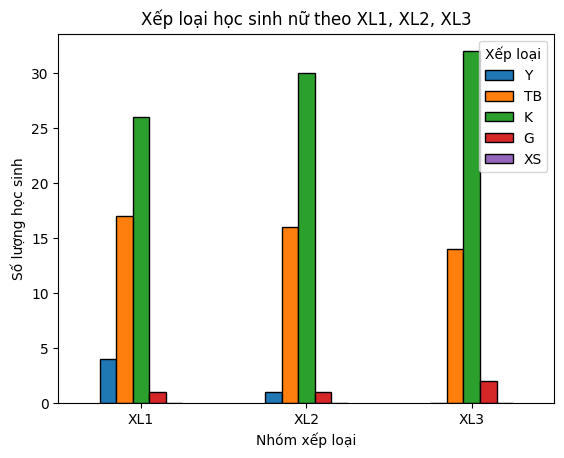

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Câu 1: Trực quan học sinh nữ theo XL1, XL2, XL3 dạng unstacked
df_nu = df[df['GT'] == 'F']

xl_order = ['Y', 'TB', 'K', 'G', 'XS']
data_xl = pd.DataFrame({
    'XL1': df_nu['XL1'].value_counts(),
    'XL2': df_nu['XL2'].value_counts(),
    'XL3': df_nu['XL3'].value_counts()
}).reindex(xl_order).fillna(0)

data_xl.T.plot(kind='bar', edgecolor='black')
plt.title('Xếp loại học sinh nữ theo XL1, XL2, XL3')
plt.xlabel('Nhóm xếp loại')
plt.ylabel('Số lượng học sinh')
plt.xticks(rotation=0)
plt.legend(title='Xếp loại')
plt.show()

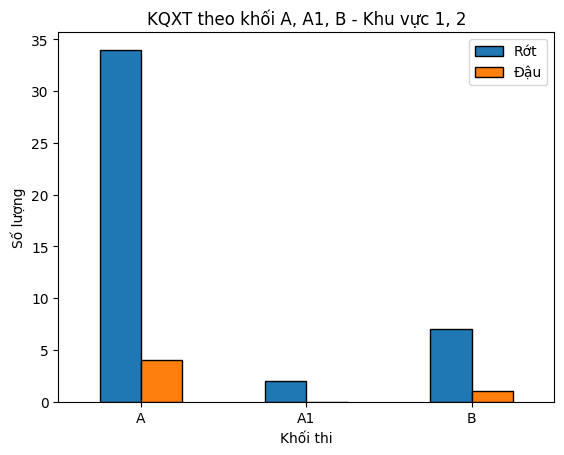

In [20]:
# Câu 2: KQXT trên học sinh khối A, A1, B thuộc khu vực 1, 2
df_c2 = df[(df['KT'].isin(['A', 'A1', 'B'])) & (df['KV'].isin(['1', '2']))]
kq = df_c2.groupby(['KT', 'KQXT']).size().unstack(fill_value=0)
kq.columns = ['Rớt', 'Đậu']
kq.plot(kind='bar', edgecolor='black')
plt.title('KQXT theo khối A, A1, B - Khu vực 1, 2')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

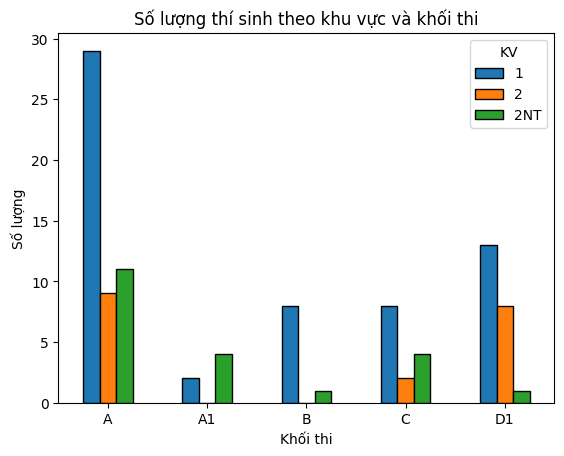

In [21]:
# Câu 3: Số lượng thí sinh từng khu vực theo khối thi
df.groupby(['KT', 'KV']).size().unstack(fill_value=0).plot(kind='bar', edgecolor='black')
plt.title('Số lượng thí sinh theo khu vực và khối thi')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

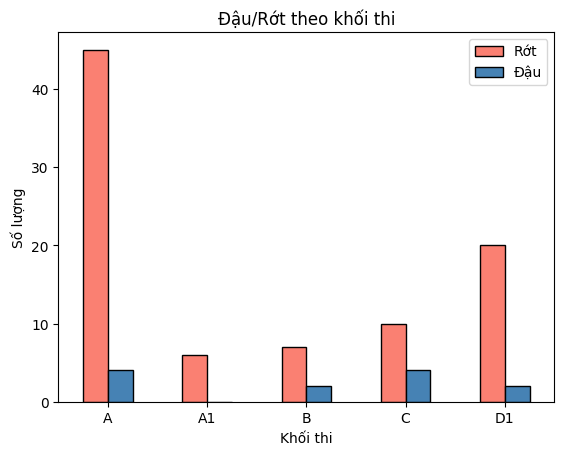

In [22]:
# Câu 4: Số lượng thí sinh đậu/rớt theo khối thi
kq_kt = df.groupby(['KT', 'KQXT']).size().unstack(fill_value=0)
kq_kt.columns = ['Rớt', 'Đậu']
kq_kt.plot(kind='bar', edgecolor='black', color=['salmon', 'steelblue'])
plt.title('Đậu/Rớt theo khối thi')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

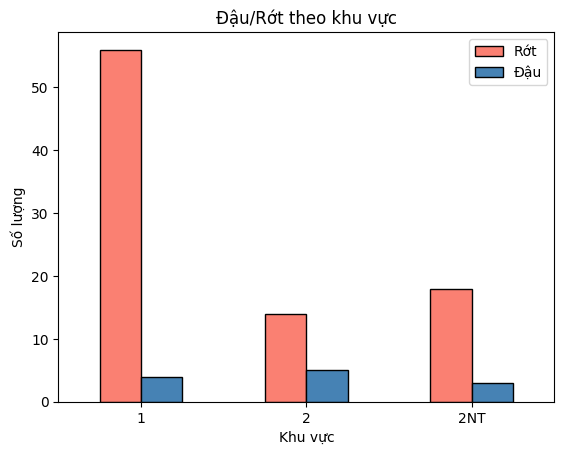

In [23]:
# Câu 5: Số lượng thí sinh đậu/rớt theo khu vực
kq_kv = df.groupby(['KV', 'KQXT']).size().unstack(fill_value=0)
kq_kv.columns = ['Rớt', 'Đậu']
kq_kv.plot(kind='bar', edgecolor='black', color=['salmon', 'steelblue'])
plt.title('Đậu/Rớt theo khu vực')
plt.xlabel('Khu vực')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

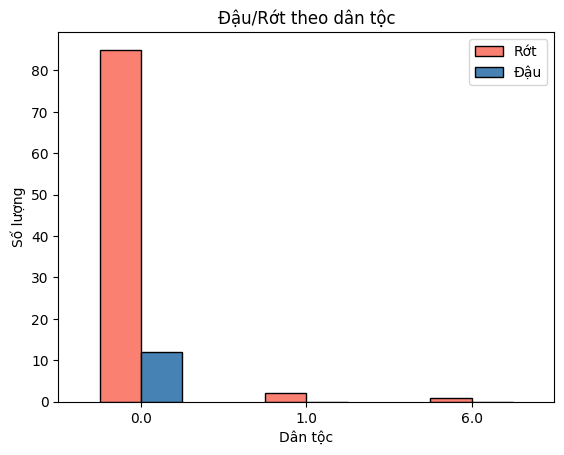

In [24]:
# Câu 6: Số lượng thí sinh đậu/rớt theo dân tộc
kq_dt = df.groupby(['DT', 'KQXT']).size().unstack(fill_value=0)
kq_dt.columns = ['Rớt', 'Đậu']
kq_dt.plot(kind='bar', edgecolor='black', color=['salmon', 'steelblue'])
plt.title('Đậu/Rớt theo dân tộc')
plt.xlabel('Dân tộc')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

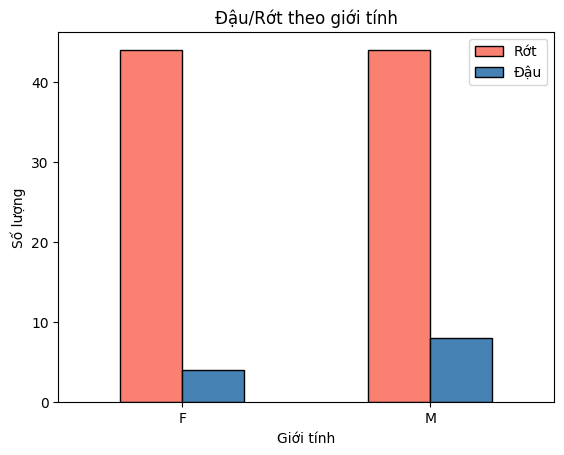

In [25]:
# Câu 7: Số lượng thí sinh đậu/rớt theo giới tính
kq_gt = df.groupby(['GT', 'KQXT']).size().unstack(fill_value=0)
kq_gt.columns = ['Rớt', 'Đậu']
kq_gt.plot(kind='bar', edgecolor='black', color=['salmon', 'steelblue'])
plt.title('Đậu/Rớt theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

In [26]:
#Phần 4

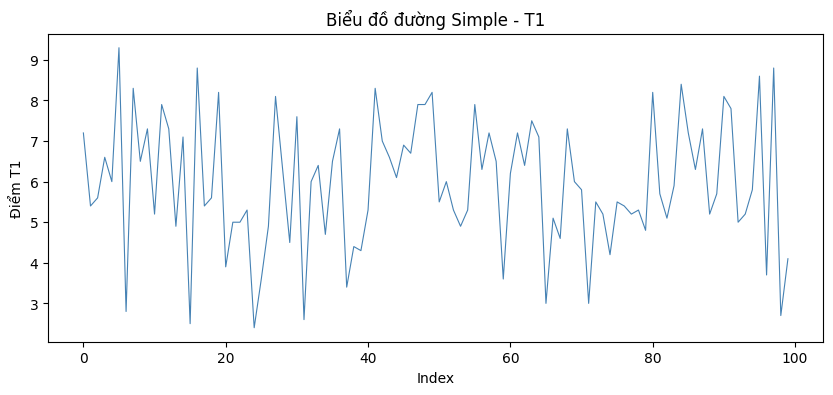

In [27]:
# Câu 1: Biểu đồ đường Simple cho biến T1
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['T1'], color='steelblue', linewidth=0.8)
plt.title('Biểu đồ đường Simple - T1')
plt.xlabel('Index')
plt.ylabel('Điểm T1')
plt.show()

In [28]:
# Câu 2: Tạo biến phân loại phanlopt1
def phan_loai_t1(x):
    if x < 5:   return 'k'
    elif x < 7: return 'tb'
    elif x < 8: return 'kha'
    else:       return 'g'

df['phanlopt1'] = df['T1'].apply(phan_loai_t1)
print(df['phanlopt1'].value_counts())

phanlopt1
tb     46
k      23
kha    19
g      12
Name: count, dtype: int64


In [29]:
# Câu 3: Bảng tần số biến phanlopt1
tan_so = df['phanlopt1'].value_counts()
tan_suat = df['phanlopt1'].value_counts(normalize=True).round(4) * 100
print(pd.DataFrame({'Tần số': tan_so, 'Tần suất (%)': tan_suat}))

           Tần số  Tần suất (%)
phanlopt1                      
tb             46          46.0
k              23          23.0
kha            19          19.0
g              12          12.0


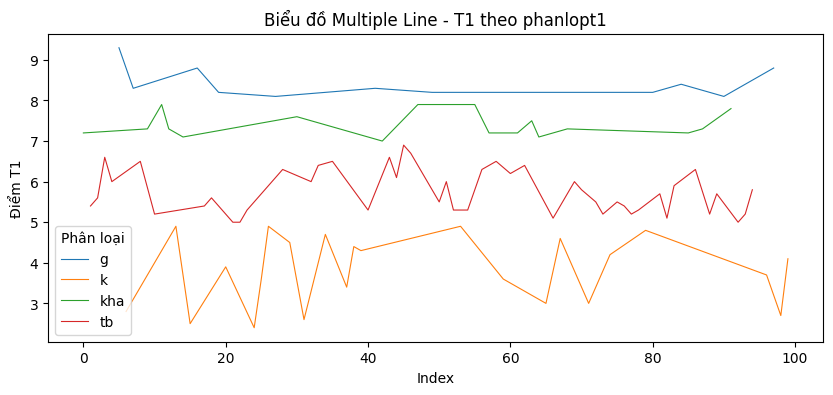

In [30]:
# Câu 4: Biểu đồ đường Multiple Line - T1 theo phanlopt1
plt.figure(figsize=(10, 4))
for nhom, group in df.groupby('phanlopt1'):
    plt.plot(group.index, group['T1'], label=nhom, linewidth=0.8)
plt.title('Biểu đồ Multiple Line - T1 theo phanlopt1')
plt.xlabel('Index')
plt.ylabel('Điểm T1')
plt.legend(title='Phân loại')
plt.show()

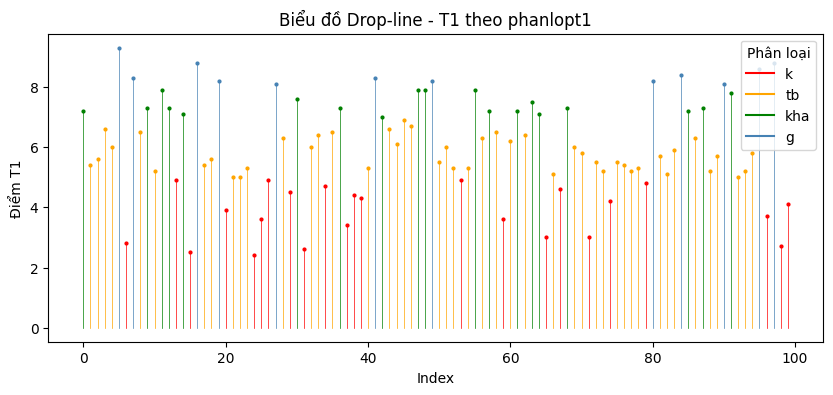

In [31]:
# Câu 5: Biểu đồ Drop-line - T1 theo phanlopt1
fig, ax = plt.subplots(figsize=(10, 4))
colors = {'k': 'red', 'tb': 'orange', 'kha': 'green', 'g': 'steelblue'}
for _, row in df.iterrows():
    color = colors[row['phanlopt1']]
    ax.plot([row.name, row.name], [0, row['T1']], color=color, linewidth=0.5)
    ax.plot(row.name, row['T1'], 'o', color=color, markersize=2)
plt.title('Biểu đồ Drop-line - T1 theo phanlopt1')
plt.xlabel('Index')
plt.ylabel('Điểm T1')
handles = [plt.Line2D([0],[0], color=c, label=l) for l, c in colors.items()]
plt.legend(handles=handles, title='Phân loại')
plt.show()

=== Mô tả T1 ===
count    100.00
mean       5.95
std        1.61
min        2.40
25%        5.00
50%        5.85
75%        7.20
max        9.30
Name: T1, dtype: float64
Skewness: -0.1782
Kurtosis: -0.4801


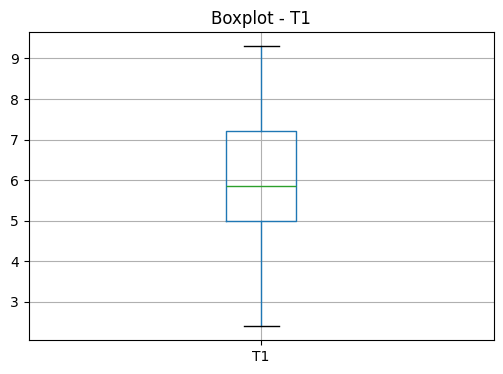

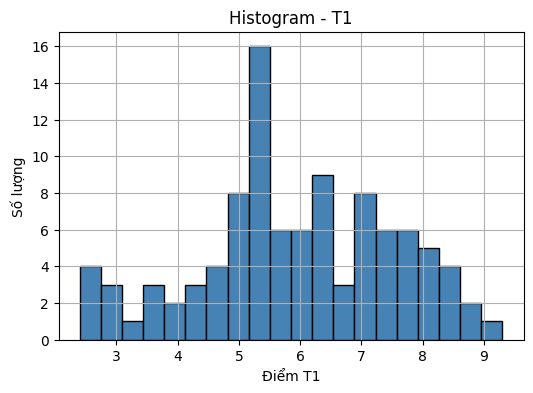

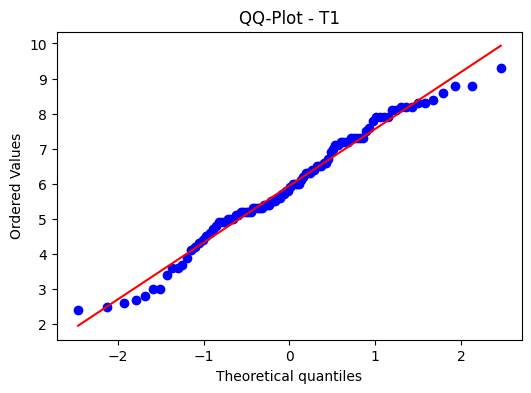

In [32]:
import scipy.stats as stats

# Câu 1: Mô tả và khảo sát phân phối T1
print("=== Mô tả T1 ===")
print(df['T1'].describe().round(2))
print(f"Skewness: {df['T1'].skew():.4f}")
print(f"Kurtosis: {df['T1'].kurt():.4f}")

# Boxplot
plt.figure(figsize=(6, 4))
df.boxplot(column='T1')
plt.title('Boxplot - T1')
plt.show()

# Histogram
plt.figure(figsize=(6, 4))
df['T1'].hist(bins=20, edgecolor='black', color='steelblue')
plt.title('Histogram - T1')
plt.xlabel('Điểm T1')
plt.ylabel('Số lượng')
plt.show()

# QQ-Plot
plt.figure(figsize=(6, 4))
stats.probplot(df['T1'], dist="norm", plot=plt)
plt.title('QQ-Plot - T1')
plt.show()


=== Nhóm: g ===
count    12.00
mean      8.44
std       0.37
min       8.10
25%       8.20
50%       8.30
75%       8.65
max       9.30
Name: T1, dtype: float64


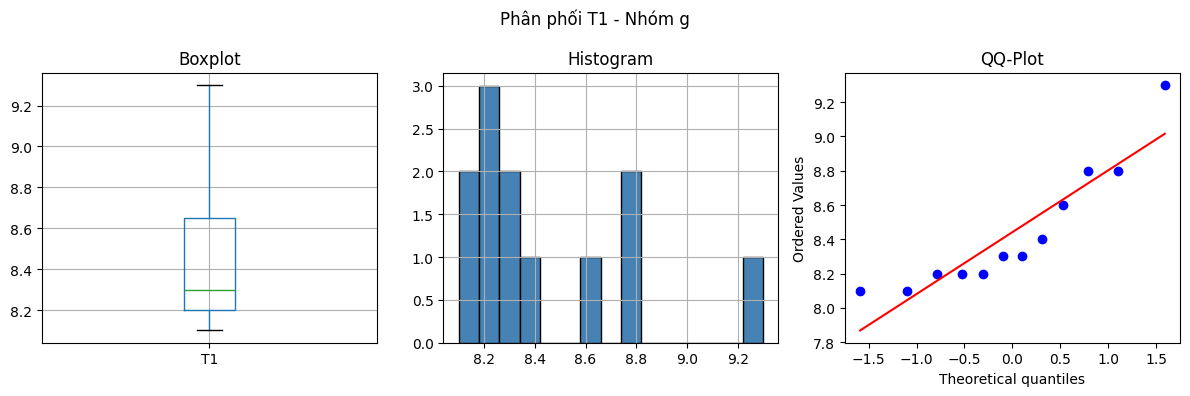


=== Nhóm: k ===
count    23.00
mean      3.80
std       0.86
min       2.40
25%       3.00
50%       3.90
75%       4.55
max       4.90
Name: T1, dtype: float64


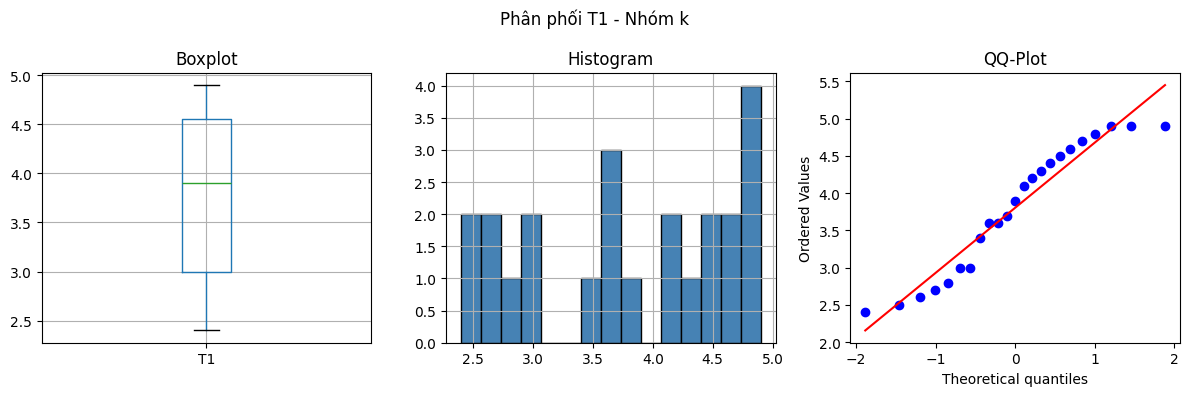


=== Nhóm: kha ===
count    19.00
mean      7.42
std       0.31
min       7.00
25%       7.20
50%       7.30
75%       7.70
max       7.90
Name: T1, dtype: float64


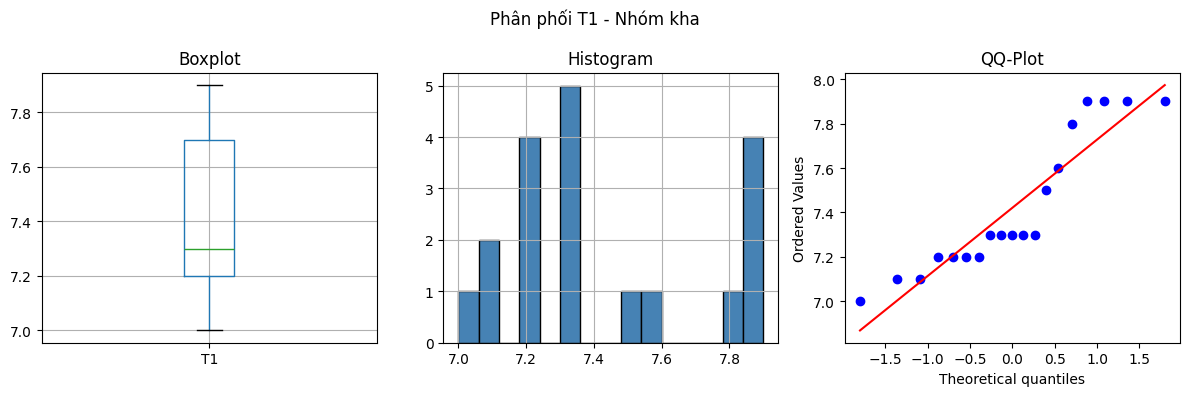


=== Nhóm: tb ===
count    46.00
mean      5.76
std       0.55
min       5.00
25%       5.30
50%       5.65
75%       6.28
max       6.90
Name: T1, dtype: float64


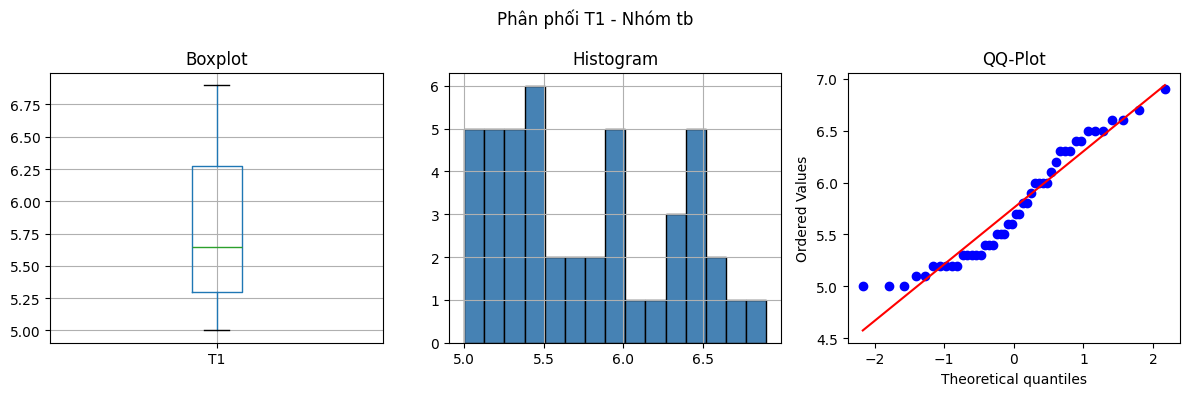

In [33]:
# Câu 2: Mô tả T1 theo từng nhóm phanlopt1
for nhom, group in df.groupby('phanlopt1'):
    print(f"\n=== Nhóm: {nhom} ===")
    print(group['T1'].describe().round(2))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f'Phân phối T1 - Nhóm {nhom}')

    group.boxplot(column='T1', ax=axes[0])
    axes[0].set_title('Boxplot')

    group['T1'].hist(bins=15, edgecolor='black', ax=axes[1], color='steelblue')
    axes[1].set_title('Histogram')

    stats.probplot(group['T1'], dist="norm", plot=axes[2])
    axes[2].set_title('QQ-Plot')

    plt.tight_layout()
    plt.show()

Covariance: 0.1128
Correlation: 0.0493


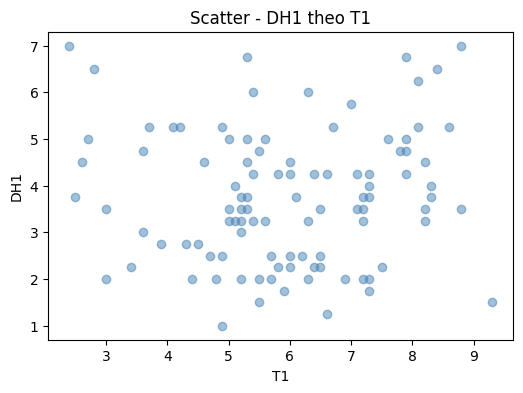

In [34]:
# Câu 3: Tương quan DH1 theo T1
print(f"Covariance: {df['T1'].cov(df['DH1']):.4f}")
print(f"Correlation: {df['T1'].corr(df['DH1']):.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(df['T1'], df['DH1'], alpha=0.5, color='steelblue')
plt.title('Scatter - DH1 theo T1')
plt.xlabel('T1')
plt.ylabel('DH1')
plt.show()

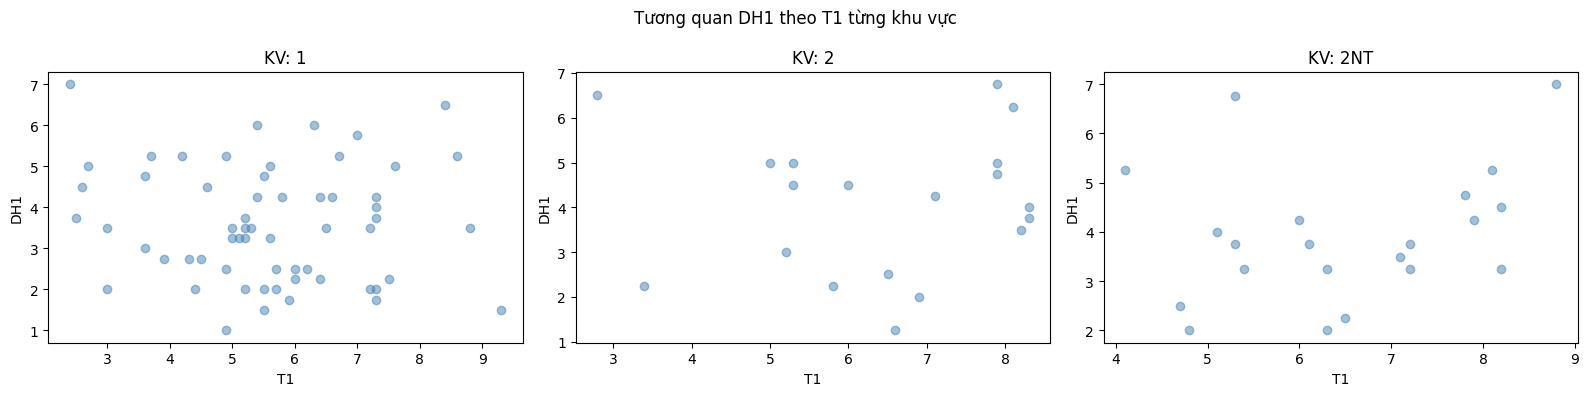

In [35]:
# Câu 4: Tương quan DH1 theo T1 trên từng khu vực
fig, axes = plt.subplots(1, len(df['KV'].unique()), figsize=(16, 4))
for ax, (kv, group) in zip(axes, df.groupby('KV')):
    ax.scatter(group['T1'], group['DH1'], alpha=0.5, color='steelblue')
    ax.set_title(f'KV: {kv}')
    ax.set_xlabel('T1')
    ax.set_ylabel('DH1')
plt.suptitle('Tương quan DH1 theo T1 từng khu vực')
plt.tight_layout()
plt.show()

=== Ma trận tương quan ===
        DH1     DH2     DH3
DH1  1.0000  0.0352  0.0187
DH2  0.0352  1.0000 -0.0915
DH3  0.0187 -0.0915  1.0000

=== Ma trận hiệp phương sai ===
        DH1     DH2     DH3
DH1  2.0289  0.0531  0.0278
DH2  0.0531  1.1237 -0.1010
DH3  0.0278 -0.1010  1.0840


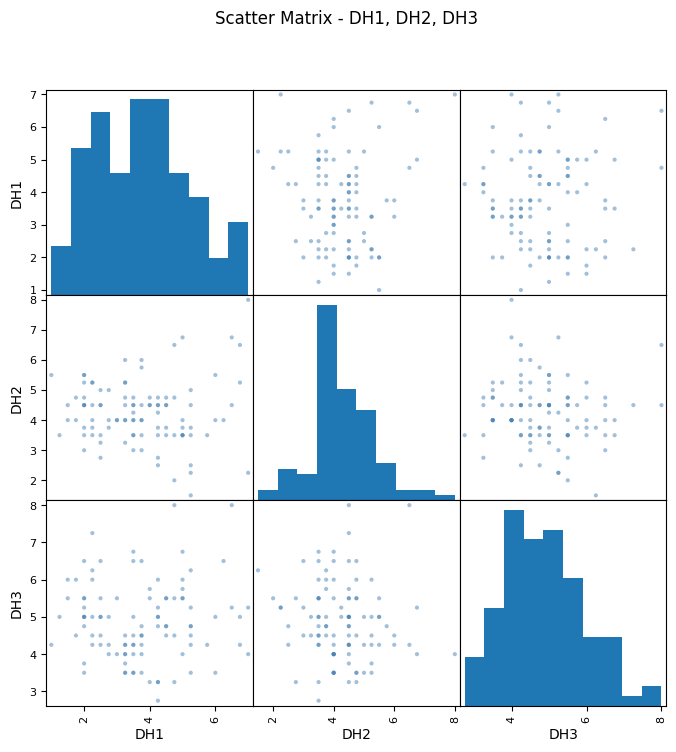

In [36]:
# Câu 5: Tương quan DH1, DH2, DH3
print("=== Ma trận tương quan ===")
print(df[['DH1','DH2','DH3']].corr().round(4))
print("\n=== Ma trận hiệp phương sai ===")
print(df[['DH1','DH2','DH3']].cov().round(4))

pd.plotting.scatter_matrix(df[['DH1','DH2','DH3']], figsize=(8, 8),
                            alpha=0.5, diagonal='hist', color='steelblue')
plt.suptitle('Scatter Matrix - DH1, DH2, DH3')
plt.show()

In [37]:
#phần 5

=== Mô tả T1 ===
count    100.00
mean       5.95
std        1.61
min        2.40
25%        5.00
50%        5.85
75%        7.20
max        9.30
Name: T1, dtype: float64
Skewness: -0.1782
Kurtosis: -0.4801


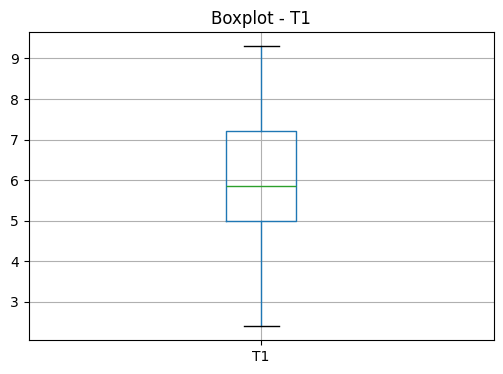

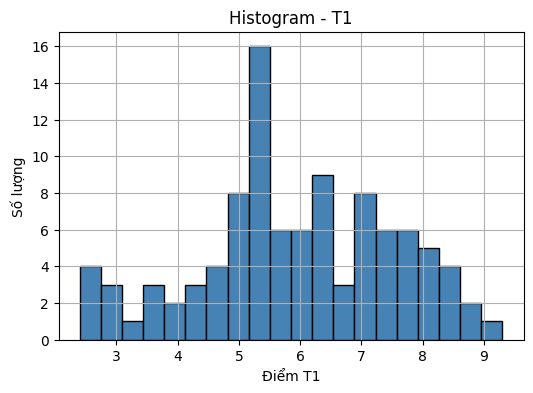

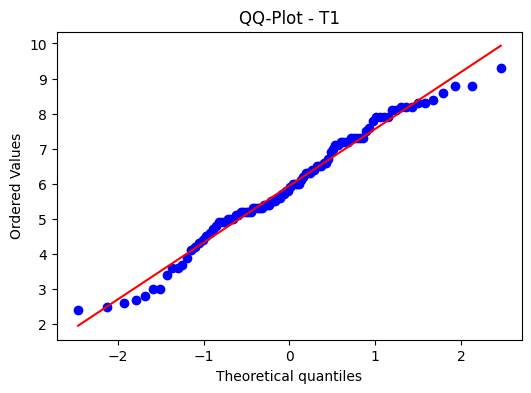

In [38]:
import scipy.stats as stats

# Câu 1: Mô tả và khảo sát phân phối T1
print("=== Mô tả T1 ===")
print(df['T1'].describe().round(2))
print(f"Skewness: {df['T1'].skew():.4f}")
print(f"Kurtosis: {df['T1'].kurt():.4f}")

# Boxplot
plt.figure(figsize=(6, 4))
df.boxplot(column='T1')
plt.title('Boxplot - T1')
plt.show()

# Histogram
plt.figure(figsize=(6, 4))
df['T1'].hist(bins=20, edgecolor='black', color='steelblue')
plt.title('Histogram - T1')
plt.xlabel('Điểm T1')
plt.ylabel('Số lượng')
plt.show()

# QQ-Plot
plt.figure(figsize=(6, 4))
stats.probplot(df['T1'], dist="norm", plot=plt)
plt.title('QQ-Plot - T1')
plt.show()


=== Nhóm: g ===
count    12.00
mean      8.44
std       0.37
min       8.10
25%       8.20
50%       8.30
75%       8.65
max       9.30
Name: T1, dtype: float64


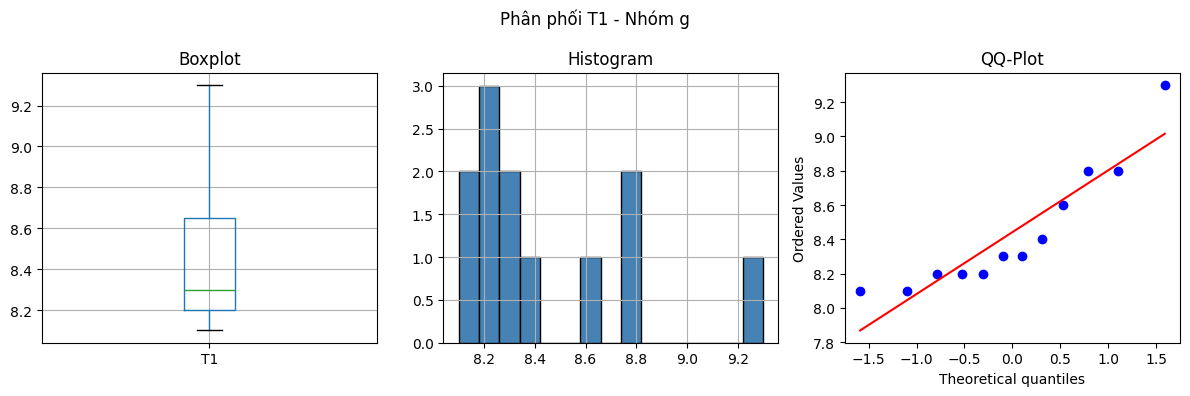


=== Nhóm: k ===
count    23.00
mean      3.80
std       0.86
min       2.40
25%       3.00
50%       3.90
75%       4.55
max       4.90
Name: T1, dtype: float64


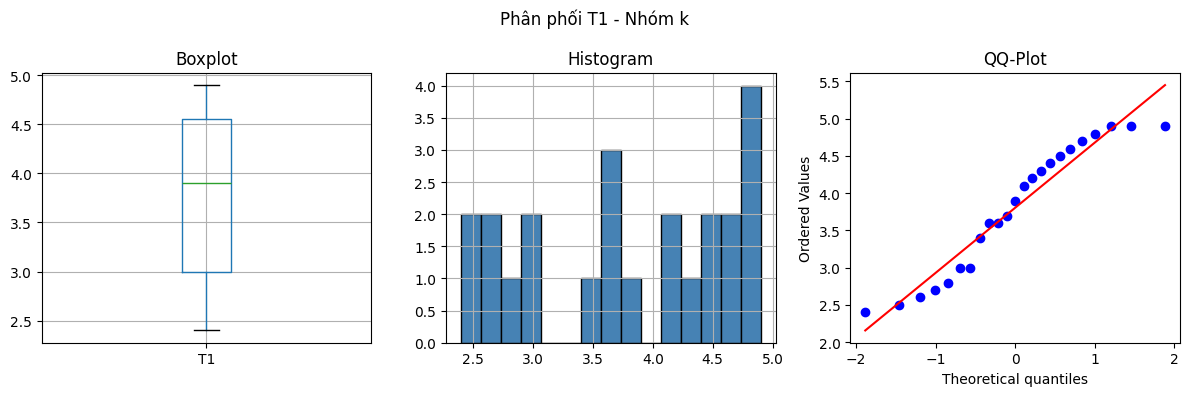


=== Nhóm: kha ===
count    19.00
mean      7.42
std       0.31
min       7.00
25%       7.20
50%       7.30
75%       7.70
max       7.90
Name: T1, dtype: float64


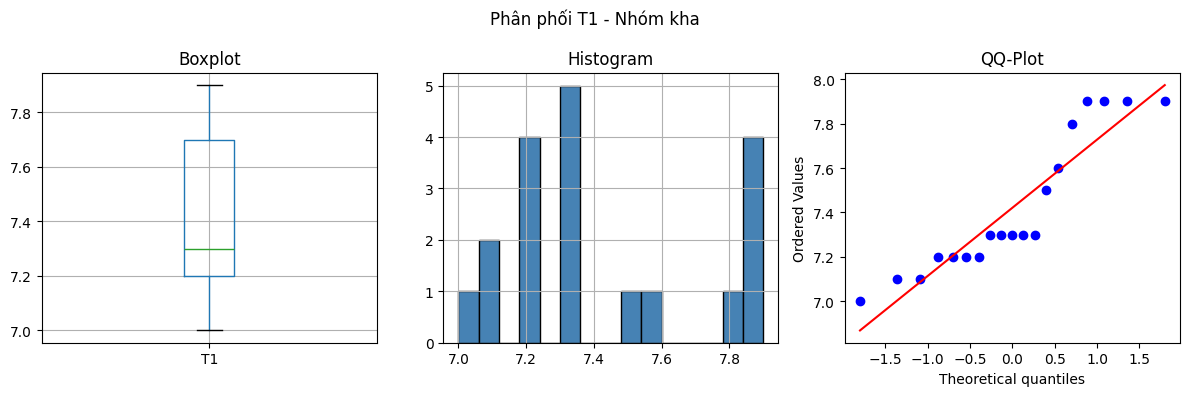


=== Nhóm: tb ===
count    46.00
mean      5.76
std       0.55
min       5.00
25%       5.30
50%       5.65
75%       6.28
max       6.90
Name: T1, dtype: float64


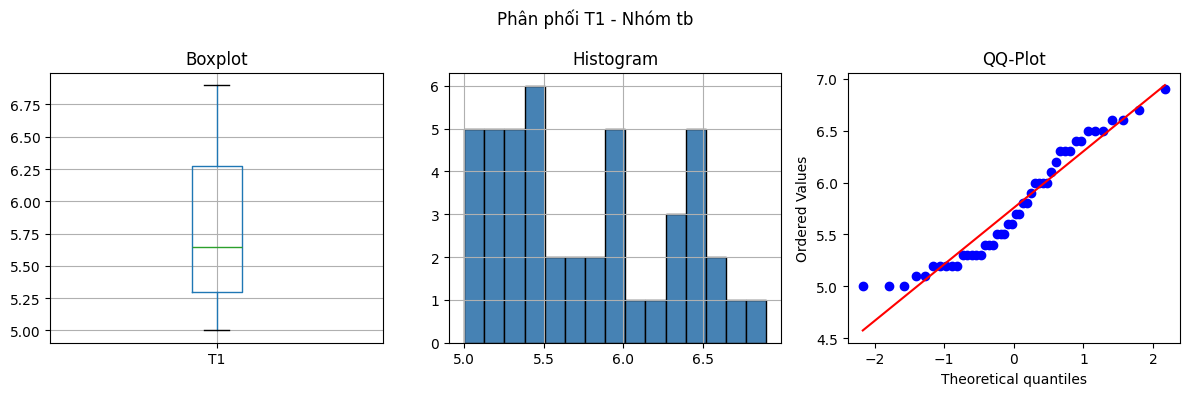

In [39]:
# Câu 2: Mô tả T1 theo từng nhóm phanlopt1
for nhom, group in df.groupby('phanlopt1'):
    print(f"\n=== Nhóm: {nhom} ===")
    print(group['T1'].describe().round(2))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f'Phân phối T1 - Nhóm {nhom}')

    group.boxplot(column='T1', ax=axes[0])
    axes[0].set_title('Boxplot')

    group['T1'].hist(bins=15, edgecolor='black', ax=axes[1], color='steelblue')
    axes[1].set_title('Histogram')

    stats.probplot(group['T1'], dist="norm", plot=axes[2])
    axes[2].set_title('QQ-Plot')

    plt.tight_layout()
    plt.show()

Covariance: 0.1128
Correlation: 0.0493


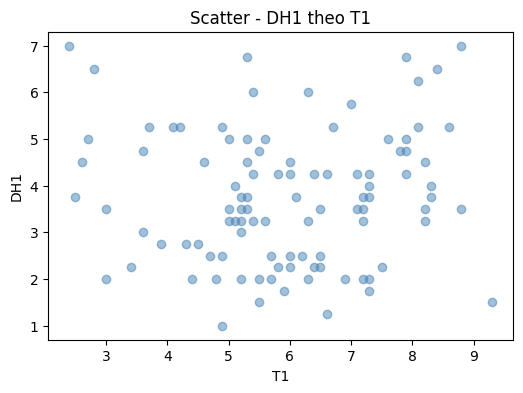

In [40]:
# Câu 3: Tương quan DH1 theo T1
print(f"Covariance: {df['T1'].cov(df['DH1']):.4f}")
print(f"Correlation: {df['T1'].corr(df['DH1']):.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(df['T1'], df['DH1'], alpha=0.5, color='steelblue')
plt.title('Scatter - DH1 theo T1')
plt.xlabel('T1')
plt.ylabel('DH1')
plt.show()

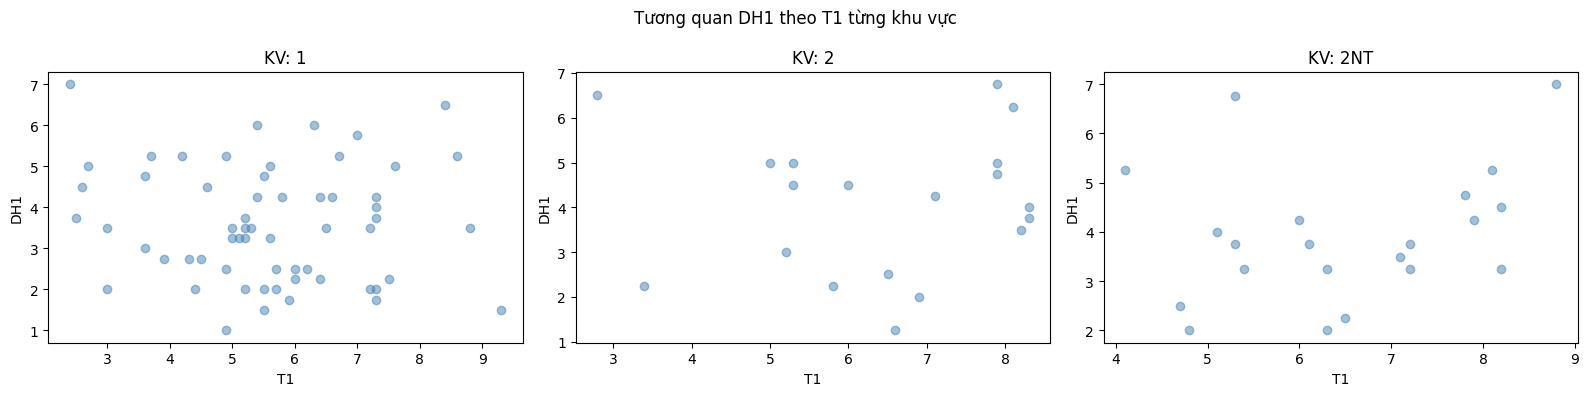

In [41]:
# Câu 4: Tương quan DH1 theo T1 trên từng khu vực
fig, axes = plt.subplots(1, len(df['KV'].unique()), figsize=(16, 4))
for ax, (kv, group) in zip(axes, df.groupby('KV')):
    ax.scatter(group['T1'], group['DH1'], alpha=0.5, color='steelblue')
    ax.set_title(f'KV: {kv}')
    ax.set_xlabel('T1')
    ax.set_ylabel('DH1')
plt.suptitle('Tương quan DH1 theo T1 từng khu vực')
plt.tight_layout()
plt.show()

=== Ma trận tương quan ===
        DH1     DH2     DH3
DH1  1.0000  0.0352  0.0187
DH2  0.0352  1.0000 -0.0915
DH3  0.0187 -0.0915  1.0000

=== Ma trận hiệp phương sai ===
        DH1     DH2     DH3
DH1  2.0289  0.0531  0.0278
DH2  0.0531  1.1237 -0.1010
DH3  0.0278 -0.1010  1.0840


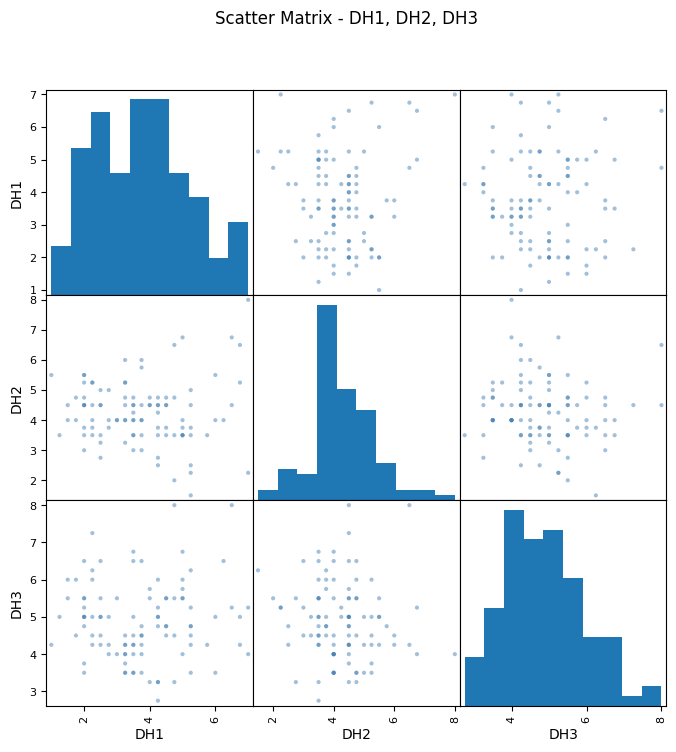

In [42]:
# Câu 5: Tương quan DH1, DH2, DH3
print("=== Ma trận tương quan ===")
print(df[['DH1','DH2','DH3']].corr().round(4))
print("\n=== Ma trận hiệp phương sai ===")
print(df[['DH1','DH2','DH3']].cov().round(4))

pd.plotting.scatter_matrix(df[['DH1','DH2','DH3']], figsize=(8, 8),
                            alpha=0.5, diagonal='hist', color='steelblue')
plt.suptitle('Scatter Matrix - DH1, DH2, DH3')
plt.show()